In [194]:
import json


with open('../runs/tac_embed_eval/last_v_last.jsonl', 'r') as f:
    lines = f.readlines()
    
json_data = []
for l in lines:
    json_data.append(json.loads(l))


In [196]:
r1_scores = [d['response1'].split('Output')[-1].split('[')[-1].split(']')[0].split(',') for d in json_data]
r1_scores = [(float(s[0]), float(s[1])) for s in r1_scores]

In [197]:
r2_scores = [d['response2'].split('Output')[-1].split('[')[-1].split(']')[0].split(',') for d in json_data]
r2_scores = [(float(s[0]), float(s[1])) for s in r2_scores]

In [198]:
combined_scores_1 = [s[0] for s in r1_scores]
separate_scores_1 = [s[1] for s in r1_scores]

combined_scores_2 = [s[1] for s in r2_scores]
separate_scores_2 = [s[0] for s in r2_scores]

In [201]:
# number of times the rankings are inconsistent

invalid = []
c_wins = []
s_wins = []
equal = []

for i, (c1, s1, s2, c2) in enumerate(zip(combined_scores_1, separate_scores_1, separate_scores_2, combined_scores_2)):
    if c1 > s1 and s2 > c2:
        invalid.append(i)
        continue
    if c1 < 0 or s1 < 0 or s2 < 0 or c2 < 0:
        invalid.append(i)
        continue
    # if c1 > s1 and s2 < c2:
    #     c_wins.append(i)
    # if c1 < s1 and s2 > c2:
    #     s_wins.append(i)
    if c1 + c2 > s1 + s2:
        c_wins.append(i)
    if c1 + c2 < s1 + s2:
        s_wins.append(i)
        
    if c1 + c2 == s1 + s2:
        equal.append(i)
            

In [202]:
print (f'Combined wins: {len(c_wins) / (len(combined_scores_1) - len(invalid))}')
print (f'Separate wins: {len(s_wins) / (len(combined_scores_1) - len(invalid))}')
print (f'Equal Score: {len(equal) / (len(combined_scores_1) - len(invalid))}')


Combined wins: 0.444698703279939
Separate wins: 0.2379862700228833
Equal Score: 0.3173150266971777


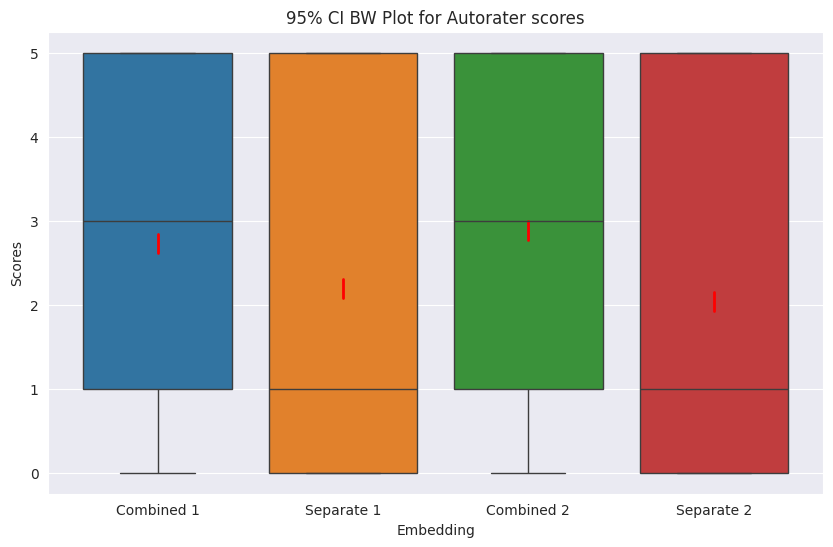

In [203]:
                import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


c1 = [combined_scores_1[i] for i in range(len(combined_scores_1)) if i not in invalid]
c2 = [combined_scores_2[i] for i in range(len(combined_scores_1)) if i not in invalid]
s1 = [separate_scores_1[i] for i in range(len(combined_scores_1)) if i not in invalid]
s2 = [separate_scores_2[i] for i in range(len(combined_scores_1)) if i not in invalid]

# c1 = combined_scores_1
# c2 = combined_scores_2
# s1 = separate_scores_1
# s2 = separate_scores_2

# Combine data into a list
data = [c1, s1, c2, s2]

# Function to calculate 95% confidence interval
def conf_interval(data, confidence=0.95):
    n = len(data)
    m = np.mean(data)
    se = stats.sem(data)
    h = se * stats.t.ppf((1 + confidence) / 2., n-1)
    return m, m-h, m+h

# Calculate confidence intervals
conf_intervals = [conf_interval(d) for d in data]

# Plotting the boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=data)

# Adding the confidence intervals
for i, ci in enumerate(conf_intervals):
    plt.plot([i, i], [ci[1], ci[2]], color='red', linewidth=2)

# Customizing the plot
plt.xticks(ticks=range(4), labels=['Combined 1', 'Separate 1', 'Combined 2', 'Separate 2'])
plt.title('95% CI BW Plot for Autorater scores')
plt.xlabel('Embedding')
plt.ylabel('Scores')

# Show the plot
plt.show()